# Phase 3 - Nettoyage selon les 6 Piliers
Application des corrections identifiées en Phase 2

In [ ]:
import pandas as pd
import numpy as np
import re
import warnings
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
warnings.filterwarnings('ignore')

# cconnexion à la base de données
load_dotenv('../.env') 

DB_HOST = os.getenv('DB_HOST', 'host.docker.internal')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'games_db')
DB_USER = os.getenv('POSTGRES_USER', 'postgres')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')

CONNECTION_STRING = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Chargement des données depuis PostgreSQL
try:
    engine = create_engine(CONNECTION_STRING)
    df_raw = pd.read_sql("SELECT * FROM games_brut", engine)
    df = df_raw.copy()
    print(f"Données chargées depuis PostgreSQL")
except Exception as e:
    print(f"Erreur de connexion PostgreSQL: {e}")
    # Fallback vers fichier au cas ou
    df_raw = pd.read_excel('../data/Bronze/games_brut.xlsx')
    df = df_raw.copy()
    print("Utilisation du fichier Excel en fallback")

print(f"Dataset original: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Cellules totales: {df.shape[0] * df.shape[1]:,}")
print(f"Valeurs manquantes: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.1f}%)")

Dataset original: 122,611 lignes x 40 colonnes
Cellules totales: 4,904,440
Valeurs manquantes: 826,424 (16.9%)


In [ ]:
# Fonction utilitaire pour sauvegarder en CSV et PostgreSQL
def save_to_csv_and_postgres(df, csv_path, table_name, if_exists='replace'):
    """
    Sauvegarde un DataFrame en CSV et dans PostgreSQL
    """
    # Sauvegarder en CSV
    df.to_csv(csv_path, index=False)
    
    # Sauvegarder en PostgreSQL
    try:
        df.to_sql(table_name, engine, if_exists=if_exists, index=False, method='multi', chunksize=1000)
        print(f"{csv_path} → Sauvé en CSV et PostgreSQL ({table_name})")
        return True
    except Exception as e:
        print(f"Erreur PostgreSQL pour {table_name}: {e}")
        print(f"Seul le fichier CSV a été sauvé: {csv_path}")
        return False

## 1. Complétude :  Traitement des valeurs manquantes

In [125]:
# 1.1 Suppression des colonnes >95% null
cols_to_drop = ['Movies', 'Score rank', 'Metacritic url']
print(f"Avant : {df.shape[1]} colonnes")
df = df.drop(columns=cols_to_drop)
print(f"Après : {df.shape[1]} colonnes")
print(f"Colonnes supprimées: {cols_to_drop}")

Avant : 40 colonnes
Après : 37 colonnes
Colonnes supprimées: ['Movies', 'Score rank', 'Metacritic url']


In [126]:
# 1.2 Remplissage des valeurs manquantes critiques

# Name: supprimer les lignes sans nom (inutilisables)
before = len(df)
df = df.dropna(subset=['Name'])
print(f"Lignes sans Name supprimées: {before - len(df)}")

# Developers/Publishers: remplacer par "Unknown"
df['Developers'] = df['Developers'].fillna('Unknown')
df['Publishers'] = df['Publishers'].fillna('Unknown')
print("Developers/Publishers null -> 'Unknown'")

# Genres/Categories: remplacer par "Uncategorized"
df['Genres'] = df['Genres'].fillna('Uncategorized')
df['Categories'] = df['Categories'].fillna('Uncategorized')
print("Genres/Categories null -> 'Uncategorized'")

# Tags: remplacer par chaîne vide (optionnel)
df['Tags'] = df['Tags'].fillna('Untagged')
print("Tags null -> Untagged")

# About the game: remplacer par "No description"
df['About the game'] = df['About the game'].fillna('No description available')
print("About the game null -> 'No description available'")

Lignes sans Name supprimées: 1
Developers/Publishers null -> 'Unknown'
Genres/Categories null -> 'Uncategorized'
Tags null -> Untagged
About the game null -> 'No description available'


## 2. Unicité - Dédoublonnage

In [127]:
# Vérification des doublons
duplicates_appid = df[df.duplicated(subset=['AppID'], keep=False)]
duplicates_name = df[df.duplicated(subset=['Name'], keep=False)]

print(f"Doublons sur AppID (clé primaire): {len(duplicates_appid)}")
print(f"Doublons sur Name: {len(duplicates_name)}")

# Les doublons sur Name sont légitimes (éditions différentes)
# On garde tous les enregistrements car AppID est unique

# Suppression des doublons complets (si existants)
before = len(df)
df = df.drop_duplicates()
print(f"\nDoublons complets supprimés: {before - len(df)}")

Doublons sur AppID (clé primaire): 0
Doublons sur Name: 2115

Doublons complets supprimés: 0


## 3. Exactitude - Correction des formats invalides

In [128]:
# 3.1 Correction des emails invalides
email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'

def validate_email(email):
    if pd.isna(email):
        return email
    if re.match(email_pattern, str(email)):
        return email
    return None  # Marquer comme null si invalide

before_invalid = df['Support email'].notna().sum() - df['Support email'].dropna().str.match(email_pattern, na=False).sum()
df['Support email'] = df['Support email'].apply(validate_email)
after_invalid = df['Support email'].notna().sum() - df['Support email'].dropna().str.match(email_pattern, na=False).sum()

print(f"Emails invalides corrigés (→ null): {before_invalid}")
print(f"Emails invalides restants: {after_invalid}")

Emails invalides corrigés (→ null): 769
Emails invalides restants: 0


In [129]:
# 3.2 Correction des prix négatifs (si il y en a )
negative_prices = (df['Price'] < 0).sum()
df.loc[df['Price'] < 0, 'Price'] = 0
print(f"Prix négatifs corrigés → 0: {negative_prices}")

# 3.3 Nettoyage des noms (trim espaces)
df['Name'] = df['Name'].str.strip()
print("Noms nettoyés (espaces supprimés)")

Prix négatifs corrigés → 0: 0
Noms nettoyés (espaces supprimés)


## 4. Validité - Conformité aux règles métier

In [130]:
# 4.1 Required age: borner entre 0 et 21
invalid_age = ((df['Required age'] < 0) | (df['Required age'] > 21)).sum()
df.loc[df['Required age'] < 0, 'Required age'] = 0
df.loc[df['Required age'] > 21, 'Required age'] = 18
print(f"Ages invalides corrigés: {invalid_age}")

# 4.2 Metacritic score: borner entre 0 et 100
invalid_meta = ((df['Metacritic score'] < 0) | (df['Metacritic score'] > 100)).sum()
df.loc[df['Metacritic score'] < 0, 'Metacritic score'] = 0
df.loc[df['Metacritic score'] > 100, 'Metacritic score'] = 100
print(f"Metacritic scores invalides corrigés: {invalid_meta}")

# 4.3 Discount: borner entre 0 et 100
invalid_discount = ((df['Discount'] < 0) | (df['Discount'] > 100)).sum()
df.loc[df['Discount'] < 0, 'Discount'] = 0
df.loc[df['Discount'] > 100, 'Discount'] = 100
print(f"Discounts invalides corrigés: {invalid_discount}")

print("\nToutes les valeurs sont maintenant dans les plages valides")

Ages invalides corrigés: 0
Metacritic scores invalides corrigés: 0
Discounts invalides corrigés: 0

Toutes les valeurs sont maintenant dans les plages valides


## 5. Cohérence - Correction des règles inter-colonnes

In [131]:
# 5.1 Correction des jeux "Free to Play" avec prix > 0
# Mettre le prix à 0 pour les jeux taggés F2P
free_tags = df['Tags'].str.contains('Free to Play', case=False, na=False)
f2p_with_price = free_tags & (df['Price'] > 0)

print(f"Jeux F2P avec prix > 0 détectés: {f2p_with_price.sum()}")

# Correction: on met le prix à 0 pour ces jeux
df.loc[f2p_with_price, 'Price'] = 0
print(f"Prix corrigé à 0 pour {f2p_with_price.sum()} jeux Free to Play")

Jeux F2P avec prix > 0 détectés: 319
Prix corrigé à 0 pour 319 jeux Free to Play


In [132]:
# 5.2 Ajout d'une colonne calculée: Total Reviews
df['Total reviews'] = df['Positive'] + df['Negative']

# 5.3 Ajout d'une colonne calculée: Review Score (%)
df['Review score'] = np.where(
    df['Total reviews'] > 0,
    (df['Positive'] / df['Total reviews'] * 100).round(1),
    0
)
print(" Colonnes calculées ajoutées: 'Total reviews', 'Review score'")

 Colonnes calculées ajoutées: 'Total reviews', 'Review score'


## 6. Actualité - Gestion des données obsolètes

In [133]:
# 6.1 Correction des dates futures (si existantes)
today = pd.Timestamp.now()
future_dates = df['Release date'] > today
print(f"Dates futures détectées: {future_dates.sum()}")

# Si dates futures, les corriger à aujourd'hui
df.loc[future_dates, 'Release date'] = today
print(f"Dates futures corrigées: {future_dates.sum()}")

# 6.2 Ajout d'une colonne: Année de sortie
df['Release year'] = df['Release date'].dt.year
print("Colonne 'Release year' ajoutée")

# 6.3 Marquage des jeux "anciens" (avant 2015)
df['Is legacy'] = df['Release year'] < 2015
legacy_count = df['Is legacy'].sum()
print(f"Colonne 'Is legacy' ajoutée ({legacy_count} jeux marqués comme legacy)")

Dates futures détectées: 0
Dates futures corrigées: 0
Colonne 'Release year' ajoutée
Colonne 'Is legacy' ajoutée (3493 jeux marqués comme legacy)


## Normalisation - Colonnes multi-valeurs (Tags, Genres, Categories)

In [134]:
# 1 Extraction du genre/tag/catégorie principal (le premier de la liste)
df['Primary_genre'] = df['Genres'].str.split(',').str[0].str.strip()
df['Primary_tag'] = df['Tags'].str.split(',').str[0].str.strip()
df['Primary_category'] = df['Categories'].str.split(',').str[0].str.strip()

print("Colonnes principales extraites:")
print(f"   - Primary_genre: {df['Primary_genre'].nunique()} valeurs uniques")
print(f"   - Primary_tag: {df['Primary_tag'].nunique()} valeurs uniques")
print(f"   - Primary_category: {df['Primary_category'].nunique()} valeurs uniques")

print("\nTop 10 genres principaux:")
print(df['Primary_genre'].value_counts().head(10))

Colonnes principales extraites:
   - Primary_genre: 28 valeurs uniques
   - Primary_tag: 420 valeurs uniques
   - Primary_category: 32 valeurs uniques

Top 10 genres principaux:
Primary_genre
Action           45888
Adventure        24053
Casual           23826
Indie            10723
Uncategorized     8412
Simulation        2449
RPG               1910
Strategy          1585
Free To Play       870
Racing             549
Name: count, dtype: int64


In [135]:
# 2 One-Hot Encoding des top 15 tags les plus fréquents
# D'abord, identifier les tags les plus communs
all_tags = df['Tags'].str.split(',').explode().str.strip()
top_tags = all_tags.value_counts().head(15).index.tolist()
top_tags = [t for t in top_tags if t]

print(f"Top 15 tags identifiés: {top_tags}\n")

# Créer les colonnes binaires
for tag in top_tags:
    col_name = f"Has_{tag.replace(' ', '_').replace('-', '_')}"
    df[col_name] = df['Tags'].str.contains(tag, case=False, na=False).astype(int)

print(f"{len(top_tags)} colonnes binaires créées pour les tags")
print(f"   Exemple: Has_Indie, Has_Action, Has_Singleplayer...")

Top 15 tags identifiés: ['Singleplayer', 'Indie', 'Untagged', 'Action', 'Casual', 'Adventure', '2D', '3D', 'Simulation', 'Strategy', 'Puzzle', 'Atmospheric', 'RPG', 'Colorful', 'Pixel Graphics']

15 colonnes binaires créées pour les tags
   Exemple: Has_Indie, Has_Action, Has_Singleplayer...


In [136]:
# 3 Comptage du nombre de tags/genres/categories par jeu
df['Tag_count'] = df['Tags'].str.split(',').str.len().fillna(0).astype(int)
df['Genre_count'] = df['Genres'].str.split(',').str.len().fillna(0).astype(int)
df['Category_count'] = df['Categories'].str.split(',').str.len().fillna(0).astype(int)

print("Colonnes de comptage ajoutées:")
print(f"   - Tag_count: min={df['Tag_count'].min()}, max={df['Tag_count'].max()}, mean={df['Tag_count'].mean():.1f}")
print(f"   - Genre_count: min={df['Genre_count'].min()}, max={df['Genre_count'].max()}, mean={df['Genre_count'].mean():.1f}")
print(f"   - Category_count: min={df['Category_count'].min()}, max={df['Category_count'].max()}, mean={df['Category_count'].mean():.1f}")

Colonnes de comptage ajoutées:
   - Tag_count: min=1, max=21, mean=9.9
   - Genre_count: min=1, max=19, mean=2.8
   - Category_count: min=1, max=32, mean=4.2


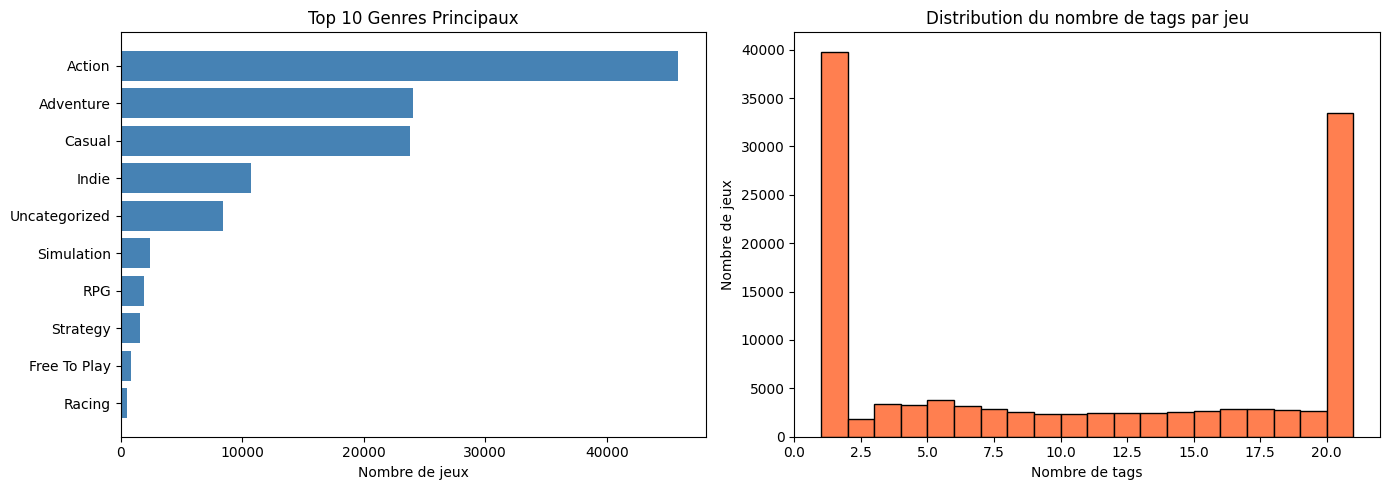


Dataset final: 62 colonnes (dont 15 colonnes de tags binaires)


In [137]:
# 4 Visualisation des genres principaux
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre distribution
genre_counts = df['Primary_genre'].value_counts().head(10)
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
axes[0].set_xlabel('Nombre de jeux')
axes[0].set_title('Top 10 Genres Principaux')

# Tag count distribution
axes[1].hist(df['Tag_count'], bins=20, color='coral', edgecolor='black')
axes[1].set_xlabel('Nombre de tags')
axes[1].set_ylabel('Nombre de jeux')
axes[1].set_title('Distribution du nombre de tags par jeu')

plt.tight_layout()
plt.show()

print(f"\nDataset final: {df.shape[1]} colonnes (dont {len(top_tags)} colonnes de tags binaires)")

## 7. Nettoyage textuel - Caractères spéciaux 

In [138]:
# 7.1 Nettoyage des caractères spéciaux dans les noms
def clean_name(name):
    if pd.isna(name):
        return name
    name = re.sub(r'[™®©]', '', str(name))
    # Garder le nom original mais créer une version "clean" pour recherche
    return name.strip()

# Créer une colonne "Name_clean" pour les recherches
df['Name_clean'] = df['Name'].apply(clean_name)

# Compter les noms avec caractères non-ASCII (japonais, coréen, russe, etc.)
non_ascii_names = df['Name'].str.contains(r'[^\x00-\x7F]', regex=True, na=False).sum()
print(f"Noms nettoyés (™®© supprimés)")
print(f"   Jeux avec caractères non-ASCII (japonais, coréen...): {non_ascii_names}")

Noms nettoyés (™®© supprimés)
   Jeux avec caractères non-ASCII (japonais, coréen...): 7564


## 8. Parsing - Transformation des colonnes textuelles

In [139]:
# 8.1 Parser "Estimated owners" : "0 - 20000" -> Owners_min, Owners_max
def parse_owners(value):
    if pd.isna(value):
        return 0, 0
    try:
        parts = str(value).replace(',', '').split(' - ')
        return int(parts[0]), int(parts[1])
    except:
        return 0, 0

df[['Owners_min', 'Owners_max']] = df['Estimated owners'].apply(
    lambda x: pd.Series(parse_owners(x))
)

# Calculer une estimation moyenne
df['Owners_estimate'] = (df['Owners_min'] + df['Owners_max']) / 2

print("'Estimated owners' parsé en colonnes numériques:")
print(f"   - Owners_min: min={df['Owners_min'].min():,}, max={df['Owners_min'].max():,}")
print(f"   - Owners_max: min={df['Owners_max'].min():,}, max={df['Owners_max'].max():,}")
print(f"   - Owners_estimate: moyenne={df['Owners_estimate'].mean():,.0f}")

'Estimated owners' parsé en colonnes numériques:
   - Owners_min: min=0, max=100,000,000
   - Owners_max: min=0, max=200,000,000
   - Owners_estimate: moyenne=85,720


## 9. Outliers - Détection et traitement des valeurs aberrantes

In [140]:
# 9.1 Détection des prix aberrants
price_outliers = df[df['Price'] > 100]
print(f"Prix suspects (> 100$): {len(price_outliers)} jeux")
print(price_outliers[['Name', 'Price']].head(10))

# Créer un flag pour les outliers (au lieu de les supprimer)
df['Price_outlier'] = df['Price'] > 100
print(f"\nColonne 'Price_outlier' créée ({df['Price_outlier'].sum()} jeux )")

Prix suspects (> 100$): 305 jeux
                                Name   Price
331    Hidden Industries Top-Down 3D  199.99
2035                  Knights Shadow  199.99
2476                      眼睛（眼球）结构研究  199.99
3154               Bounce racing car  199.99
4176       Hidden Farm 2 Top-Down 3D  199.99
4235  Bicycle Challenge - Wastelands  199.99
4572          Reincarnation of Ocean  199.99
4618      Hidden World 5 Top-Down 3D  199.99
4637      Hidden World 7 Top-Down 3D  199.99
5227             3D PUZZLE - Bedroom  199.99

Colonne 'Price_outlier' créée (305 jeux )


In [141]:
# 9.2 Détection des playtimes aberrants (> 10000 heures = 600000 minutes)
playtime_outliers = df[df['Average playtime forever'] > 600000]
print(f"Playtime suspects (> 10000h): {len(playtime_outliers)} jeux")

# 9.3 Vérification cohérence plateformes
no_platform = df[(df['Windows'] == False) & (df['Mac'] == False) & (df['Linux'] == False)]
print(f"\nJeux sans aucune plateforme: {len(no_platform)}")
if len(no_platform) > 0:
    # Corriger: mettre Windows = True par défaut (Steam est principalement Windows)
    df.loc[(df['Windows'] == False) & (df['Mac'] == False) & (df['Linux'] == False), 'Windows'] = True
    print(f"Corrigé: Windows = True pour {len(no_platform)} jeux")

Playtime suspects (> 10000h): 2 jeux

Jeux sans aucune plateforme: 0


## 10. Export Silver et création des tables Gold

In [ ]:
# 10.1 Export Silver - Dataset nettoyé complet
save_to_csv_and_postgres(df, '../data/Silver/games_clean.csv', 'games_clean')

# 10.1 LECTURE DU SILVER POUR CRÉATION DU GOLD
df_silver = pd.read_csv('../data/Silver/games_clean.csv')
print(f"\nSilver chargé: {len(df_silver):,} lignes")

# 10.2 Créer table GAME_TAGS (AppID, Tag)
game_tags = df_silver[['AppID', 'Tags']].copy()
game_tags = game_tags.assign(Tag=game_tags['Tags'].str.split(',')).explode('Tag')
game_tags['Tag'] = game_tags['Tag'].str.strip()
# Filtrer les tags vides et les NaN
game_tags = game_tags[game_tags['Tag'].notna() & (game_tags['Tag'] != '')][['AppID', 'Tag']]

print(f"\nTable GAME_TAGS créée: {len(game_tags):,} lignes")
print(f"   {df_silver['AppID'].nunique()} jeux -> {game_tags['Tag'].nunique()} tags uniques")

# Sauvegarder en CSV et PostgreSQL
save_to_csv_and_postgres(game_tags, '../data/Gold/game_tags.csv', 'game_tags')

Silver exporté: ../data/Silver/games_clean.csv (122,610 lignes, 67 colonnes)

Silver chargé: 122,610 lignes

Table GAME_TAGS créée: 1,219,291 lignes
   122610 jeux -> 453 tags uniques
   Exporté: ../data/Gold/game_tags.csv


In [ ]:
# 10.3 Créer table GAME_GENRES (AppID, Genre)
game_genres = df_silver[['AppID', 'Genres']].copy()
game_genres = game_genres.assign(Genre=game_genres['Genres'].str.split(',')).explode('Genre')
game_genres['Genre'] = game_genres['Genre'].str.strip()
# Filtrer les genres vides, NaN et "Uncategorized"
game_genres = game_genres[game_genres['Genre'].notna() & (game_genres['Genre'] != '') & (game_genres['Genre'] != 'Uncategorized')][['AppID', 'Genre']]

print(f"Table GAME_GENRES créée: {len(game_genres):,} lignes")
save_to_csv_and_postgres(game_genres, '../data/Gold/game_genres.csv', 'game_genres')

# 10.4 Créer table GAME_DEVELOPERS (AppID, Developer) - une ligne par développeur
game_developers = df_silver[['AppID', 'Developers']].copy()
game_developers = game_developers.assign(Developer=game_developers['Developers'].str.split(',')).explode('Developer')
game_developers['Developer'] = game_developers['Developer'].str.strip()
# Filtrer les devs vides, NaN et "Unknown"
game_developers = game_developers[game_developers['Developer'].notna() & (game_developers['Developer'] != '') & (game_developers['Developer'] != 'Unknown')][['AppID', 'Developer']]

print(f"\nTable GAME_DEVELOPERS créée: {len(game_developers):,} lignes")
print(f"   {df_silver['AppID'].nunique()} jeux → {game_developers['Developer'].nunique()} développeurs uniques")
save_to_csv_and_postgres(game_developers, '../data/Gold/game_developers.csv', 'game_developers')

# 10.5 Créer table GAME_PUBLISHERS (AppID, Publisher)
game_publishers = df_silver[['AppID', 'Publishers']].copy()
game_publishers = game_publishers.assign(Publisher=game_publishers['Publishers'].str.split(',')).explode('Publisher')
game_publishers['Publisher'] = game_publishers['Publisher'].str.strip()
# Filtrer les publishers vides, NaN et "Unknown"
game_publishers = game_publishers[game_publishers['Publisher'].notna() & (game_publishers['Publisher'] != '') & (game_publishers['Publisher'] != 'Unknown')][['AppID', 'Publisher']]

print(f"\nTable GAME_PUBLISHERS créée: {len(game_publishers):,} lignes")
print(f"   {df_silver['AppID'].nunique()} jeux → {game_publishers['Publisher'].nunique()} publishers uniques")
save_to_csv_and_postgres(game_publishers, '../data/Gold/game_publishers.csv', 'game_publishers')

Table GAME_GENRES créée: 329,318 lignes
   Exporté: ../data/Gold/game_genres.csv

Table GAME_DEVELOPERS créée: 127,802 lignes
   122610 jeux → 75469 développeurs uniques
   Exporté: ../data/Gold/game_developers.csv

Table GAME_PUBLISHERS créée: 121,071 lignes
   122610 jeux → 62672 publishers uniques
   Exporté: ../data/Gold/game_publishers.csv


In [ ]:
# 10.6 Créer table GAMES_GOLD (colonnes essentielles uniquement)
# Cette table ne contient pas les colonnes multi-valeurs (Tags, Genres, Categories, Developers, Publishers)
# car elles sont dans les tables de liaison

# Sélection des colonnes pour la table Gold
gold_columns = [
    'AppID',
    'Name',
    'Release date',
    'Estimated owners',
    'Peak CCU',
    'Required age',
    'Price',
    'Discount',
    'DLC count',
    'About the game',
    'Supported languages',
    'Full audio languages',
    'Reviews',
    'Header image',
    'Website',
    'Support url',
    'Support email',
    'Windows',
    'Mac',
    'Linux',
    'Metacritic score',
    'User score',
    'Positive',
    'Negative',
    'Achievements',
    'Recommendations',
    'Notes',
    'Average playtime forever',
    'Average playtime two weeks',
    'Median playtime forever',
    'Median playtime two weeks',
    'Screenshots',
    'Tag_count',
    'Genre_count',
    'Release year',
    'Is legacy',
    'Name_clean'
]

# Ajouter les colonnes Owners si elles existent
if 'Owners_min' in df_silver.columns:
    gold_columns.extend(['Owners_min', 'Owners_max', 'Owners_estimate'])

# Ajouter les flags outliers si ils existent
if 'Price_outlier' in df_silver.columns:
    gold_columns.extend(['Price_outlier', 'Playtime_outlier'])

games_gold = df_silver[[col for col in gold_columns if col in df_silver.columns]].copy()

# Sauvegarder en CSV et PostgreSQL
save_to_csv_and_postgres(games_gold, '../data/Gold/games_gold.csv', 'games_gold')

print(f"\nTable GAMES_GOLD créée: {len(games_gold):,} lignes, {len(games_gold.columns)} colonnes")


Table GAMES_GOLD créée: 122,610 lignes, 28 colonnes
   Exporté: ../data/Gold/games_gold.csv


## 7. Comparaison Avant/Après

In [145]:
# Comparaison Avant/Après
print("Comparaison Avant / Après Nettoyage")

# Métriques avant
raw_rows, raw_cols = df_raw.shape
raw_null = df_raw.isnull().sum().sum()
raw_completeness = (1 - raw_null / (raw_rows * raw_cols)) * 100

# Métriques après
clean_rows, clean_cols = df.shape
clean_null = df.isnull().sum().sum()
clean_completeness = (1 - clean_null / (clean_rows * clean_cols)) * 100

print(f"\n{'Métrique':<25} {'AVANT':<15} {'APRÈS':<15} {'Δ':<10}")
print("-" * 70)
print(f"{'Lignes':<25} {raw_rows:<15,} {clean_rows:<15,} {clean_rows - raw_rows:<10,}")
print(f"{'Colonnes':<25} {raw_cols:<15} {clean_cols:<15} {clean_cols - raw_cols:<10}")
print(f"{'Valeurs nulles':<25} {raw_null:<15,} {clean_null:<15,} {clean_null - raw_null:<10,}")
print(f"{'Complétude (%)':<25} {raw_completeness:<15.1f} {clean_completeness:<15.1f} {clean_completeness - raw_completeness:+.1f}%")

Comparaison Avant / Après Nettoyage

Métrique                  AVANT           APRÈS           Δ         
----------------------------------------------------------------------
Lignes                    122,611         122,610         -1        
Colonnes                  40              67              27        
Valeurs nulles            826,424         381,222         -445,202  
Complétude (%)            83.1            95.4            +12.2%


## 11. Vérification des colonnes du dataset Gold

In [149]:
# Vérification du Silver exporté
df_verif = pd.read_csv('../data/Gold/games_gold.csv')
print(f"Vérification Gold: {len(df_verif):,} lignes, {len(df_verif.columns)} colonnes")
print("\nAperçu du dataset Gold:")
df_verif.head()

Vérification Gold: 122,610 lignes, 28 colonnes

Aperçu du dataset Gold:


,AppID,Name,Release date,Price,Required age,Metacritic score,Positive,Negative,Total reviews,Review score,...,Primary_category,Tag_count,Genre_count,Release year,Is legacy,Name_clean,Owners_min,Owners_max,Owners_estimate,Price_outlier
0,2539430,Black Dragon Mage Playtest,2023-08-01,0.00,0,0,0,0,0,0.0,...,Uncategorized,1,1,2023,False,Black Dragon Mage Playtest,0,0,0.0,False
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,5.24,0,0,252,3,255,98.8,...,Single-player,4,1,2016,False,Supipara - Chapter 1 Spring Has Come!,0,20000,10000.0,False
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,4.99,0,0,21,3,24,87.5,...,Single-player,16,1,2019,False,Mystery Solitaire The Black Raven,0,20000,10000.0,False
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,8.99,0,0,0,0,0,0.0,...,Single-player,1,3,2024,False,버튜버 파라노이아 - Vtuber Paranoia,0,20000,10000.0,False
4,3631080,Maze Quest VR,2025-04-24,4.99,0,0,0,0,0,0.0,...,Single-player,1,2,2025,False,Maze Quest VR,0,20000,10000.0,False


In [151]:
# Résumé des colonnes du dataset Gold
print("Colonnes du dataset Gold:")
print("-" * 40)
for i, col in enumerate(df_verif.columns, 1):
    null_pct = df_verif[col].isnull().sum() / len(df_verif) * 100
    print(f"{i:2}. {col:<30} ({null_pct:.1f}% null)")

Colonnes du dataset Gold:
----------------------------------------
 1. AppID                          (0.0% null)
 2. Name                           (0.0% null)
 3. Release date                   (0.0% null)
 4. Price                          (0.0% null)
 5. Required age                   (0.0% null)
 6. Metacritic score               (0.0% null)
 7. Positive                       (0.0% null)
 8. Negative                       (0.0% null)
 9. Total reviews                  (0.0% null)
10. Review score                   (0.0% null)
11. Peak CCU                       (0.0% null)
12. Achievements                   (0.0% null)
13. DLC count                      (0.0% null)
14. Windows                        (0.0% null)
15. Mac                            (0.0% null)
16. Linux                          (0.0% null)
17. Primary_genre                  (0.0% null)
18. Primary_tag                    (0.0% null)
19. Primary_category               (0.0% null)
20. Tag_count                      (0.0%